<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>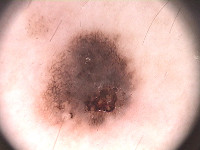</td><td>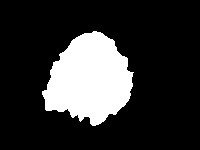</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [ ]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=75c2ea97-b158-46a6-b103-188166b4e55b
To: /content/PH2Dataset.rar
100% 162M/162M [00:00<00:00, 178MB/s]


In [ ]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [ ]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

# os.walk проходит по всем папкам внутри указанной директории и на каждом шаге возвращает три вещи:
# rootтекущая папка'PH2 Dataset images/IMD002/IMD002_lesion'dirsсписок подпапок внутри неё['папка1', 'папка2']filesсписок файлов внутри неё['IMD002_lesion.bmp']

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0]))) #imread(...) читает изображение по этому полному пути.
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [ ]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [ ]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

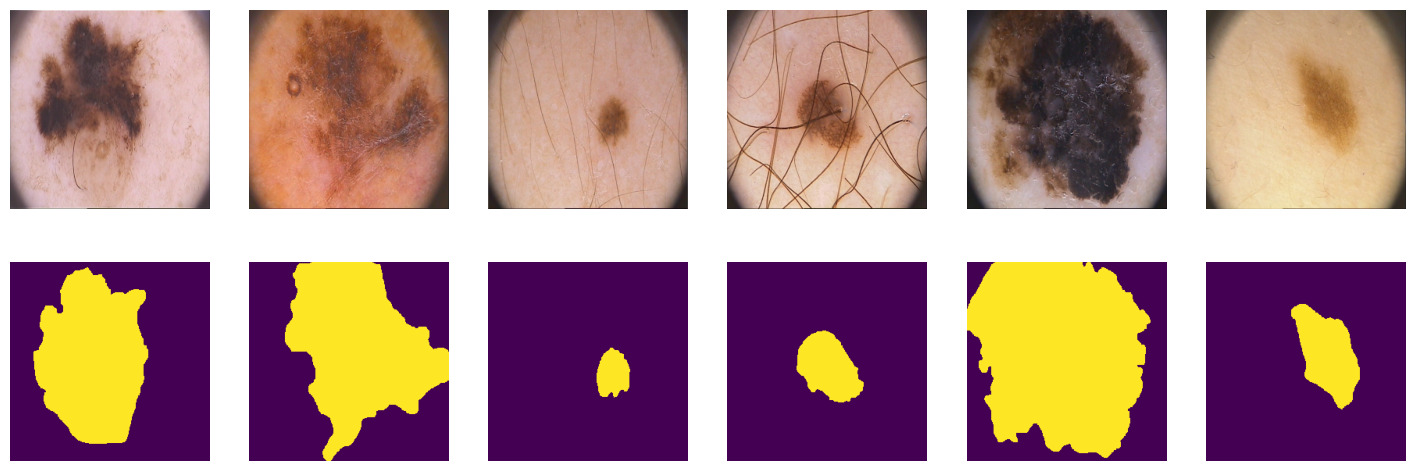

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [ ]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [ ]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [ ]:
from torch.utils.data import DataLoader
batch_size = 25

# np.rollaxis(X[tr], 3, 1)
# Изображения хранятся в формате HWC (Height, Width, Channels):
# X[tr].shape = (N, 256, 256, 3)
# #              ^    ^    ^   ^
# #         картинки  H    W  RGB
# Но PyTorch ожидает формат CHW (Channels, Height, Width):
# (N, 3, 256, 256)
# #   ^   ^    ^
# #  RGB  H    W
# rollaxis(X[tr], 3, 1) — перекатывает ось номер 3 на позицию 1:
# (N, 256, 256, 3)  →  (N, 3, 256, 256)
#          ось 3            ось

train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),


# Y[tr, np.newaxis]
# Маски имеют форму:
# Y[tr].shape = (N, 256, 256)
# Но нужно добавить размерность канала, чтобы совпадало с форматом изображений:
# Y[tr, np.newaxis].shape = (N, 1, 256, 256)
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**
## Вывод формулы BCE

**Формула [1]:**
$$\mathcal{L}_{BCE}(y, \hat{y}) = -\sum_i \left[ y_i \log \sigma(\hat{y}_i) + (1 - y_i) \log(1 - \sigma(\hat{y}_i)) \right]$$

где $\sigma(\hat{y}) = \dfrac{1}{1 + \exp(-\hat{y})}$ — сигмоида, $\hat{y}_i$ — логиты сети.

---

### Шаг 1 — раскрываем логарифмы сигмоиды

$$\log \sigma(\hat{y}) = \log \frac{1}{1 + \exp(-\hat{y})} = -\log(1 + \exp(-\hat{y}))$$

$$\log(1 - \sigma(\hat{y})) = \log \frac{\exp(-\hat{y})}{1 + \exp(-\hat{y})} = -\hat{y} - \log(1 + \exp(-\hat{y}))$$

---

### Шаг 2 — подставляем в формулу (для одного элемента)

$$\mathcal{L} = -\Big[ y \cdot \big(-\log(1+\exp(-\hat{y}))\big) + (1-y) \cdot \big(-\hat{y} - \log(1+\exp(-\hat{y}))\big) \Big]$$

Раскрываем скобки:

$$= -\Big[ -y\log(1+\exp(-\hat{y})) - (1-y)\hat{y} - (1-y)\log(1+\exp(-\hat{y})) \Big]$$

Группируем слагаемые с логарифмом:

$$= -\Big[ -(y + 1 - y)\log(1+\exp(-\hat{y})) - (1-y)\hat{y} \Big]$$

$$= \log(1+\exp(-\hat{y})) + \hat{y} - y\hat{y}$$

---

### Шаг 3 — упрощаем

Используем тождество:
$$\log(1 + \exp(\hat{y})) = \hat{y} + \log(1 + \exp(-\hat{y}))$$

Поэтому выражение принимает вид:

$$\mathcal{L} = \log(1 + \exp(\hat{y})) - y\hat{y}$$

что эквивалентно **формуле [2]:**

$$\boxed{\mathcal{L}_{BCE} = \hat{y} - y\hat{y} + \log\big(1 + \exp(-\hat{y})\big)}$$

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
bce_torch = nn.BCELoss(reduction='sum') # reduction — это то, как объединить losses по всем элементам батча в одно число.
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [ ]:
def bce_loss(y_pred, y_real):
  temp = - (y_real * torch.log(torch.sigmoid(y_pred)) + (1-y_real)*torch.log(1-torch.sigmoid(y_pred)))
  return temp.sum() #без суммы мы просто возвращаем тензор размера входных данных, где указаны лосы для каждого пикселя
  #с помощью сум мы взвращаем сумму лосов по всем пикселям

def bce_true(y_pred, y_real):
  foo = y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred))
  return foo.sum()

Проверим корректность работы на простом примере

In [ ]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.324070453643799
BCE loss честно посчитанный                = 4.324070453643799
BCE loss from torch bce_torch              = 4.324070453643799
BCE loss from torch with logits bce_torch  = 4.324070453643799


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [ ]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 13.537413597106934
BCE loss честно посчитанный               = 13.537413597106934
BCE loss from torch bce_torch             = 13.537413597106934
BCE loss from torch with logits bce_torch = 13.537413597106934


In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [ ]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 7.39MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 5.80MB/s]
Download completed


In [ ]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

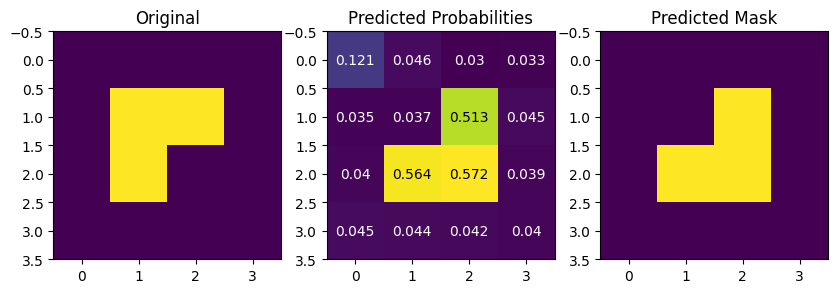

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [ ]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

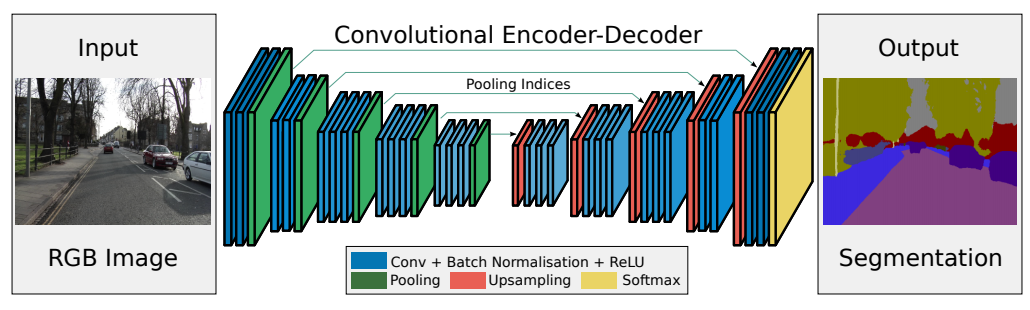

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [ ]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [ ]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [ ]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding


'''ЭТО ЧИСТО БЛОКИ ДЛЯ СЕТИ, ТУТ СЕТЬ МЫ НЕ СОЗДАЕМ ЕЩЕ'''
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
    super(DecoderBlock, self).__init__()
    self.layers = nn.ModuleList()

# Слой 1: 512 → 256  (меняем количество каналов)
# Слой 2: 256 → 256  (оставляем то же)
# Слой 3: 256 → 256  (оставляем то же)
    self.layers.append(nn.Conv2d(in_channels, out_channels,
                                     kernel_size=kernel_size, padding=padding))
    self.layers.append(nn.BatchNorm2d(out_channels))
    self.layers.append(nn.ReLU(inplace=True))

    for i in range(depth - 1):
        self.layers.append(nn.Conv2d(out_channels, out_channels,
                                         kernel_size=kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

    self.upsampling = nn.MaxUnpool2d(kernel_size=2, stride=2)

  def forward(self, x, indeces):
    x = self.upsampling(x, indeces)
    for layer in self.layers:
      x = layer(x)
    return x

Соединим блоки энкодера и декодера в модель SegNet:

In [ ]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features*2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features*4, num_features * 8, depth=3)

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features*8, num_features * 8, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features*8, num_features*8, depth = 3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth = 3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth = 3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth = 2)
        self.decoder4 = DecoderBlock(num_features, num_features, depth = 2)

        self.final = nn.Conv2d(num_features, out_channels, kernel_size=1)

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 =  self.encoder1(x)
        x, indices2 =  self.encoder2(x)
        x, indices3 =  self.encoder3(x)
        x, indices4 =  self.encoder4(x)
        # TODO
        x =  self.decoder0(x, indices4)
        x =  self.decoder1(x, indices3)
        x =  self.decoder2(x, indices2)
        x =  self.decoder3(x, indices1)
        x = self.decoder4(x, indices0)
        output = self.final(x)
        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
def train_one_epoch(model, optimizer, criterion, Loader, device):

  model.train()
  avg_loss = 0

  for X_batch, Y_batch in Loader:
    X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
    Y_pred = model(X_batch)
    loss = criterion(Y_pred, Y_batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    avg_loss += loss.item()
  avg_loss = avg_loss / len(Loader)

  return model, avg_loss

def val_one_epoch(model, optimizer, criterion, Loader, device):
  model.eval()
  avg_val_loss = 0
  iou_val = 0
  with torch.no_grad():
    for X_batch, Y_batch in Loader:
      X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
      Y_pred = model(X_batch)
      iou = iou_score(torch.sigmoid(Y_pred), Y_batch)
      loss = criterion(Y_pred, Y_batch)

      avg_val_loss += loss.item()
      iou_val += iou.item()
    avg_val_loss = avg_val_loss / len(Loader)
    iou_val = iou_val / len(Loader)
  return model, avg_val_loss, iou_val

In [ ]:
import json

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, loader, device, n=4):
    model.eval()
    X_batch, Y_batch = next(iter(loader))
    X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

    with torch.no_grad():
        Y_pred = model(X_batch)
        Y_pred = torch.sigmoid(Y_pred)  # логиты → вероятности
        Y_pred = (Y_pred > 0.5).float()  # вероятности → маска

    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    axes[0, 0].set_title('Изображение')
    axes[0, 1].set_title('Настоящая маска')
    axes[0, 2].set_title('Предсказанная маска')

    for i in range(n):
        # изображение — переводим из CHW в HWC для matplotlib
        img = X_batch[i].cpu().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img)
        axes[i, 0].axis('off')

        # настоящая маска
        axes[i, 1].imshow(Y_batch[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].axis('off')

        # предсказанная маска
        axes[i, 2].imshow(Y_pred[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def train(model, optimizer, criterion, epochs, TrainLoader, ValLoader, device, path):
  total_train_loss = []
  total_val_loss = []
  total_val_iou = []
  best_val_loss = float('inf')

  for epoch in tqdm(range(1, epochs+1)):
    model, train_loss = train_one_epoch(model, optimizer, criterion, TrainLoader, device)
    model, val_loss, val_iou = val_one_epoch(model, optimizer, criterion, ValLoader, device)

    print(f'Epoch {epoch}: train loss = {train_loss}')
    print(f'Epoch {epoch}: val loss = {val_loss}')
    print(f'Epoch {epoch}: IoU val = {val_iou}')

    total_train_loss.append(train_loss)
    total_val_loss.append(val_loss)
    total_val_iou.append(val_iou)

    stats_to_save = {
            'train_loss': [float(x) for x in total_train_loss],
            'val_loss': [float(x) for x in total_val_loss],
            'val_iou': [float(x) for x in total_val_iou],
    }

    with open(f'{path}/statistics.json', 'w') as f:
                json.dump(stats_to_save, f)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model.state_dict(), f'{path}/best_val_loss_model.pt')

    torch.save(model.state_dict(), f'{path}/epoch_{epoch+1}_val_iou.pt')

    statistics = {'train loss': total_train_loss,
                  'val_loss': total_val_loss,
                  'val_iou': total_val_iou}
    if epoch % 5 == 0:
      visualize_predictions(model, ValLoader, device, n=2)
  return model, statistics

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [ ]:
model = SegNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
path = '/content/SegNet'
epochs = 30
criterion = nn.BCEWithLogitsLoss()

In [ ]:
import os
os.makedirs('SegNet', exist_ok=True)

In [ ]:
model, stats = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, path)

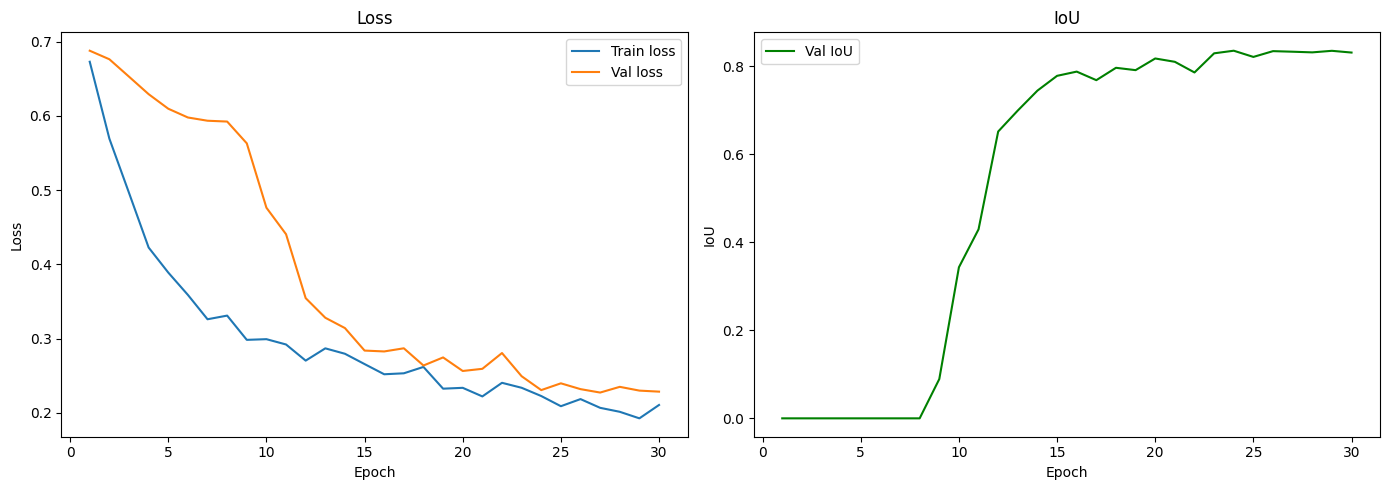

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(stats['train loss']) + 1)

# График лоссов
axes[0].plot(epochs, stats['train loss'], label='Train loss')
axes[0].plot(epochs, stats['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# График IoU
axes[1].plot(epochs, stats['val_iou'], label='Val IoU', color='green')
axes[1].set_title('IoU')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].legend()

plt.tight_layout()
plt.show()

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [ ]:
def test(model, test_dataloader, device, ckpt_path, ckpt_name):
    model.load_state_dict(torch.load(f'{ckpt_path}/{ckpt_name}'))
    model.to(device)
    model.eval()
    iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in test_dataloader:
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred = model(X_batch.to(device))
          avg_iou += iou_score(torch.sigmoid(Y_pred), Y_batch)
      avg_iou = avg_iou / len(test_dataloader)

    return avg_iou

In [ ]:
print(test(model, test_dataloader, device, path, 'best_val_loss_model.pt').item())

0.8267143964767456


test_IoU = 0.84456467628479

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [ ]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    eps = 1e-8
    probability = torch.sigmoid(logits)
    classes = (probability > threshold).float()
    tp = (classes * labels).sum()
    fp = classes.sum() - tp        # предсказали 1, а было 0
    fn = labels.sum() - tp
    score = (2*tp + eps) / (2*tp + fp+ fn+ eps)
    return score.item()

Проверим на корректность функцию dice_score:

In [ ]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice((dummpy_sample['logits'].sigmoid()), dummpy_sample['labels'].to(int))

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.3158, device='cuda:0')

In [ ]:
print("Shapes:")
print("  logits:", dummpy_sample['logits'].shape)
print("  labels:", dummpy_sample['labels'].shape)
print("  labels unique:", dummpy_sample['labels'].unique())
print("  labels sum:", dummpy_sample['labels'].sum().item())

probs = dummpy_sample['logits'].sigmoid()
preds = (probs > 0.5).float()
print("  preds sum:", preds.sum().item())

# Считаем вручную ещё раз, очень явно
tp = ((preds == 1) & (dummpy_sample['labels'] == 1)).sum().item()
fp = ((preds == 1) & (dummpy_sample['labels'] == 0)).sum().item()
fn = ((preds == 0) & (dummpy_sample['labels'] == 1)).sum().item()
tn = ((preds == 0) & (dummpy_sample['labels'] == 0)).sum().item()
print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")

manual_dice = (2*tp) / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
print(f"  manual dice: {manual_dice}")
print(f"  my dice:     {dice_score(dummpy_sample['logits'], dummpy_sample['labels'])}")
print(f"  tm dice:     {dice(probs, dummpy_sample['labels'].to(int)).item()}")

Shapes:
  logits: torch.Size([1, 1, 4, 4])
  labels: torch.Size([1, 1, 4, 4])
  labels unique: tensor([0., 1.], device='cuda:0')
  labels sum: 3.0
  preds sum: 3.0
  TP=2, FP=1, FN=1, TN=12
  manual dice: 0.6666666666666666
  my dice:     0.6666666865348816
  tm dice:     0.31578946113586426


Короче, она почему-то не совпадает, я спросил у клода. Он сказал, что в новой версии библиотеку немного поменяли и нужно подавать не логиты, а предикты модели (0 или 1)

In [ ]:
dice = DiceScore(num_classes=1, average='micro').to(device)
preds_binary = (dummpy_sample['logits'].sigmoid() > 0.5).to(int)
labels_int = dummpy_sample['labels'].to(int)
assert np.isclose(dice(preds_binary, labels_int).item(), dice_score(dummpy_sample['logits'], dummpy_sample['labels']), atol=1e-6)

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    '''
    Это лосс.
    '''
    eps = 1e-8
    probability = torch.sigmoid(logits)
    # НЕ бинаризуем! Работаем с вероятностями
    #То есть probability * labels — это «мягкий TP»: насколько сильно модель согласна с тем, что там единица. Не бинарное «угадал/не угадал», а степень уверенности.
    tp = (probability * labels).sum()
    fp = probability.sum() - tp
    fn = labels.sum() - tp
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    return 1 - score  # НЕ .item() — нужен тензор для градиентов

Проверка на корректность:

In [ ]:
# проверьте, что у вас установлена библиотека
!pip install segmentation-models-pytorch

In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    loss = -(pow((1 - (torch.sigmoid(y_pred)*y_real + (1 - torch.sigmoid(y_pred))*(1-y_real))), gamma) * (y_real * torch.log(torch.sigmoid(y_pred)) + (1-y_real)*torch.log(1-torch.sigmoid(y_pred)))).sum()
    return loss

Проверка корректности функции:

In [ ]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [ ]:
my = focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)
tv = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

print(f"my:  {my}")
print(f"tv:  {tv}")

my:  3.616124153137207
tv:  3.616123676300049


In [ ]:
assert np.isclose(
    sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum').item(),
    focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0).item(),
    atol=1e-4
)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [ ]:
def paper_inspired_loss(logits, labels, lambda_=1.0, gamma=1.0):
    prob = torch.sigmoid(logits)

    l_seg = dice_loss(logits, labels)

    l_sparse = prob.abs().mean()
    diff_h = (prob[:, :, 1:, :] - prob[:, :, :-1, :]).abs().mean()
    diff_w = (prob[:, :, :, 1:] - prob[:, :, :, :-1]).abs().mean()
    l_contiguity = diff_h + diff_w

    return l_seg + lambda_ * (l_sparse + gamma * l_contiguity)

In [ ]:
from scipy.ndimage import distance_transform_edt
def boundary_loss(logits, phi_map):
    prob = torch.sigmoid(logits)
    return (prob * phi_map).mean()
def compute_distance_map(label):
    dist_outside = distance_transform_edt(label == 0)
    dist_inside = distance_transform_edt(label == 1)
    phi = dist_outside - dist_inside
    return phi
def combined_loss(logits, labels, phi_map, alpha=0.01):
    l_regional = dice_loss(logits, labels)
    l_boundary = boundary_loss(logits, phi_map)
    return (1 - alpha) * l_regional + alpha * l_boundary

In [ ]:
def tversky_loss(logits, labels, alpha=0.3, beta=0.7, eps=1e-8):
    prob = torch.sigmoid(logits)
    tp = (prob * labels).sum()
    fp = (prob * (1 - labels)).sum()
    fn = ((1 - prob) * labels).sum()
    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return 1 - tversky

In [ ]:
import torch.nn.functional as F


def compute_local_stats(x, kernel_size=3, sigma=1.5):
    # Создаём гауссово ядро
    coords = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
    grid = torch.stack(torch.meshgrid(coords, coords, indexing='ij'))
    gaussian = torch.exp(-(grid ** 2).sum(0) / (2 * sigma ** 2))
    gaussian = gaussian / gaussian.sum()  # нормализуем к единице

    kernel = gaussian.unsqueeze(0).unsqueeze(0).to(x.device)

    pad = kernel_size // 2

    mu = F.conv2d(x, kernel, padding=pad)

    mu_sq = mu ** 2
    sigma_sq = F.conv2d(x ** 2, kernel, padding=pad) - mu_sq
    sigma_sq = torch.clamp(sigma_sq, min=0)  # на случай числовых ошибок
    std = torch.sqrt(sigma_sq + 1e-8)

    return mu, std


def structural_similarity_loss(logits, labels, kernel_size=3, sigma=1.5,
                                beta=0.1, C4=0.01, lam=0.5):
    prob = torch.sigmoid(logits)

    mu_y, std_y = compute_local_stats(labels, kernel_size, sigma)
    mu_p, std_p = compute_local_stats(prob, kernel_size, sigma)

    y_norm = (labels - mu_y + C4) / (std_y + C4)
    p_norm = (prob - mu_p + C4) / (std_p + C4)

    e = torch.abs(y_norm - p_norm)

    e_max = e.max().detach()
    mask = (e > beta * e_max).float()

    bce = F.binary_cross_entropy_with_logits(logits, labels, reduction='none')

    ssl = (e.detach() * mask * bce)
    num_hard = mask.sum().clamp(min=1)
    ssl = ssl.sum() / num_hard

    bce_mean = bce.mean()

    loss = lam * bce_mean + (1 - lam) * ssl

    return loss

In [ ]:
!pip install gudhi --break-system-packages


In [ ]:
from scipy.ndimage import label
import gudhi


def compute_persistence_diagram(likelihood, threshold=0.5):
    cc = gudhi.CubicalComplex(
        dimensions=likelihood.shape,
        top_dimensional_cells=(-likelihood).flatten()
    )
    cc.persistence()

    pairs = []
    for dim, (birth, death) in cc.persistence_pairs():
        if death == float('inf'):
            death = -likelihood.min()
        pairs.append((-birth, -death, dim))

    return pairs


def topological_loss(logits, labels, lambd=1e-4):
    prob = torch.sigmoid(logits)
    prob_np = prob[0, 0].detach().cpu().numpy()
    label_np = labels[0, 0].detach().cpu().numpy()

    gt_components, num_gt_components = label(label_np)

    cc = gudhi.CubicalComplex(
        dimensions=prob_np.shape,
        top_dimensional_cells=(-prob_np).flatten()
    )
    cc.persistence()

    loss = torch.tensor(0.0, device=logits.device)

    pairs = cc.cofaces_of_persistence_pairs()

    dim0_pairs = []
    # pairs[0] — dim 0 (connected components)
    # Каждый элемент — numpy array формы (N, 2): [[birth, death], ...]
    if len(pairs) > 0 and len(pairs[0]) > 0:
        for arr in pairs[0]:
            for row in arr:
                birth_idx = row[0]
                death_idx = row[1]

                birth_coord = np.unravel_index(birth_idx, prob_np.shape)
                death_coord = np.unravel_index(death_idx, prob_np.shape)

                birth_val = prob[0, 0, birth_coord[0], birth_coord[1]]
                death_val = prob[0, 0, death_coord[0], death_coord[1]]

                persistence = birth_val - death_val
                dim0_pairs.append((birth_val, death_val, persistence))

    dim0_pairs.sort(key=lambda x: x[2].item(), reverse=True)

    for i, (birth_val, death_val, pers) in enumerate(dim0_pairs):
        if i < num_gt_components:
            loss = loss + (1.0 - birth_val) ** 2 + death_val ** 2
        else:
            loss = loss + pers ** 2

    return lambd * loss


def total_loss_with_topo(logits, labels, lambd=1e-4):
    """
    Полный лосс: BCE + topological
    """
    bce = F.binary_cross_entropy_with_logits(logits, labels)
    topo = topological_loss(logits, labels, lambd)
    return bce + topo

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [ ]:
import os

# 1. Paper-inspired loss (из статьи про FER)
def criterion_paper_inspired(logits, labels):
    return paper_inspired_loss(logits, labels, lambda_=1.0, gamma=1.0)

# 2. Boundary loss — нужен phi_map, считаем на лету
def criterion_boundary(logits, labels):
    # Считаем phi_map для каждого изображения в батче
    phi_batch = []
    for i in range(labels.shape[0]):
        mask_np = labels[i, 0].cpu().numpy()
        phi = compute_distance_map(mask_np)
        phi_batch.append(phi)
    phi_map = torch.tensor(np.stack(phi_batch), dtype=torch.float32)
    phi_map = phi_map.unsqueeze(1).to(logits.device)
    return combined_loss(logits, labels, phi_map, alpha=0.01)

# 3. Tversky loss
def criterion_tversky(logits, labels):
    return tversky_loss(logits, labels, alpha=0.3, beta=0.7)

# 4. SSL (Structural Similarity Loss)
def criterion_ssl(logits, labels):
    return structural_similarity_loss(logits, labels, kernel_size=3)

# 5. Topological loss — ОЧЕНЬ медленный, по одному изображению
def criterion_topo(logits, labels):
    return total_loss_with_topo(logits, labels, lambd=1e-4)

In [ ]:
experiments = {
    'paper_inspired': criterion_paper_inspired,
    'boundary':       criterion_boundary,
    'tversky':        criterion_tversky,
    'ssl':            criterion_ssl,
}

results = {}

for name, criterion in experiments.items():
    print(f"\n{'='*50}")
    print(f"Training with {name} loss")
    print(f"{'='*50}")

    model = SegNet().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    path = f'/content/SegNet_{name}'
    os.makedirs(path, exist_ok=True)

    model, statistics = train(
        model, optimizer, criterion,
        epochs=30,
        TrainLoader=train_dataloader,
        ValLoader=valid_dataloader,
        device=device,
        path=path
    )

    results[name] = statistics

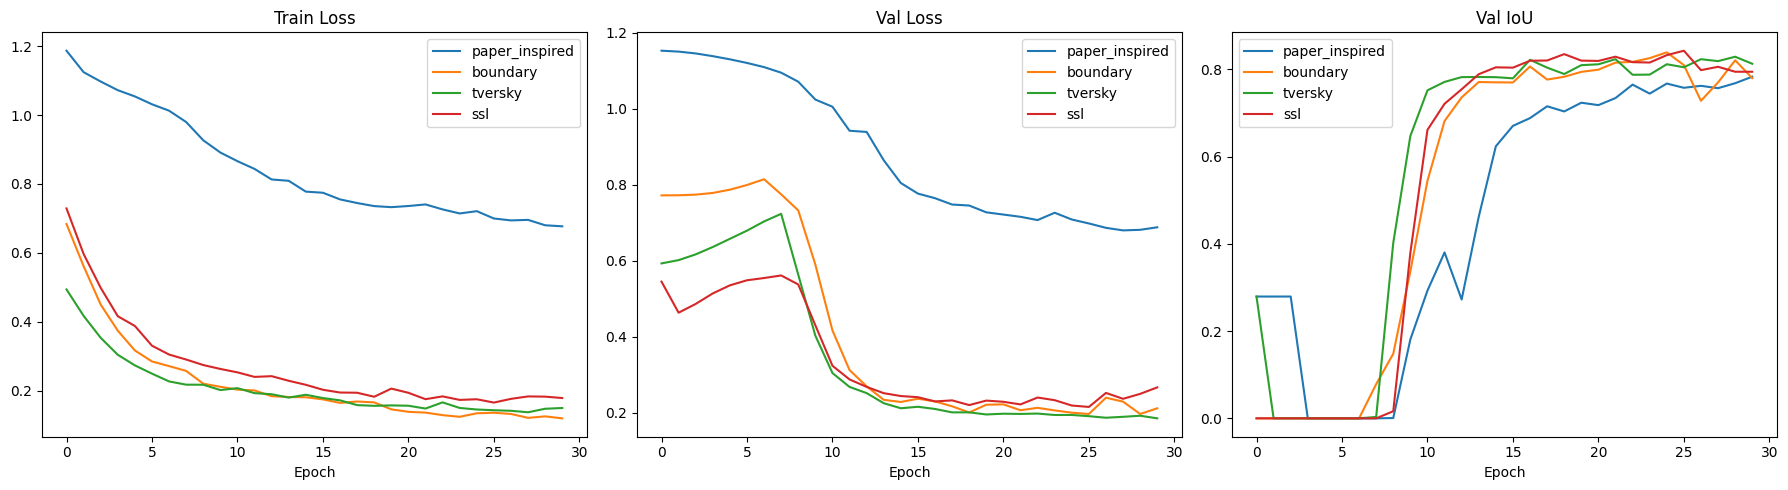


Loss                 Best IoU     Final IoU    Converge epoch
------------------------------------------------------------
paper_inspired       0.7831       0.7831       30
boundary             0.8389       0.7798       25
tversky              0.8288       0.8127       29
ssl                  0.8426       0.7944       26


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, stats in results.items():
    axes[0].plot(stats['train loss'], label=name)
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

for name, stats in results.items():
    axes[1].plot(stats['val_loss'], label=name)
axes[1].set_title('Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

for name, stats in results.items():
    axes[2].plot(stats['val_iou'], label=name)
axes[2].set_title('Val IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

# Итоговая таблица
print(f"\n{'Loss':<20} {'Best IoU':<12} {'Final IoU':<12} {'Converge epoch'}")
print('-' * 60)
for name, stats in results.items():
    ious = stats['val_iou']
    best_iou = max(ious)
    best_epoch = ious.index(best_iou) + 1
    final_iou = ious[-1]
    print(f"{name:<20} {best_iou:<12.4f} {final_iou:<12.4f} {best_epoch}")

# Сравнение лоссов для SegNet

## При каком лоссе модель сходится быстрее?

**Boundary loss** и **SSL** сходятся быстрее всего — обе достигают пиковых
значений IoU на 25–26 эпохе. **Tversky** сходится чуть позже (эпоха 29).
**Paper_inspired** — самый медленный: он продолжает улучшаться до последней
эпохи (30), а его кривая Val IoU начинает подниматься только около 10-й эпохи,
тогда как остальные стартуют на 7–8 эпохе.


По **Best IoU** лидирует **SSL** (0.8426), немного опережая boundary (0.8389).

Однако по **Final IoU** (устойчивость к концу обучения) лучше всех **Tversky**
(0.8127) — он меньше просаживается после пика. Boundary и SSL достигают
высокого пика, но к 30-й эпохе теряют 4–5% IoU, что указывает на переобучение.

**Paper_inspired** показал худший результат (0.7831) — регуляризация sparsity
и contiguity из статьи про распознавание эмоций плохо подходит для сегментации
родинок, где маска и так компактная.

## Вывод

- **Максимальное качество** → SSL (Best IoU = 0.8426)
- **Стабильность обучения** → Tversky (Final IoU = 0.8127, минимальная деградация)
- **Наименее подходящий** → Paper_inspired (худшие метрики, самая медленная сходимость)

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

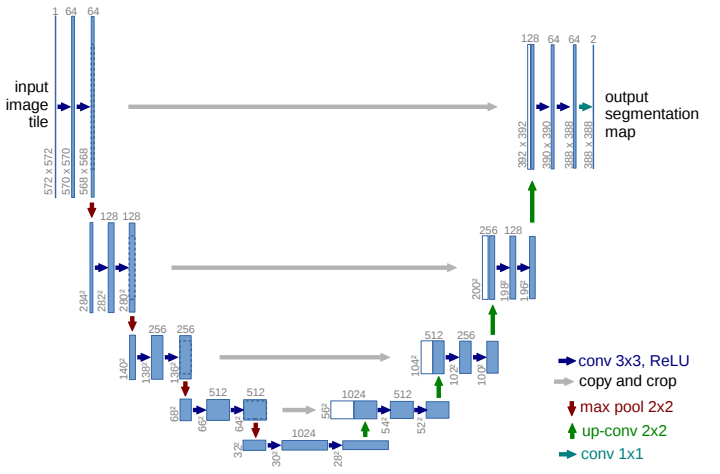

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()
        # Encoder
        self.enc1 = self._conv_block(3, 64)
        self.enc2 = self._conv_block(64, 128)
        self.enc3 = self._conv_block(128, 256)
        self.enc4 = self._conv_block(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck = self._conv_block(512, 1024)

        # Decoder — входные каналы = upconv + skip connection
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self._conv_block(1024, 512)  # 512 (up) + 512 (skip) = 1024

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self._conv_block(512, 256)   # 256 + 256 = 512

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(256, 128)   # 128 + 128 = 256

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(128, 64)    # 64 + 64 = 128

        # Final 1x1 conv
        self.final = nn.Conv2d(64, n_class, kernel_size=1)

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder + skip connections (конкатенация)
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        output = self.final(d1)
        return output

In [ ]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



In [ ]:
import os

# Лоссы
criterion_bce = nn.BCEWithLogitsLoss()

def criterion_dice(logits, labels):
    return dice_loss(logits, labels)

def criterion_focal(logits, labels):
    return focal_loss(labels, logits)

# Все эксперименты
experiments = {
    'segnet_bce':   {'model_class': SegNet,  'criterion': criterion_bce},
    'segnet_dice':  {'model_class': SegNet,  'criterion': criterion_dice},
    'segnet_focal': {'model_class': SegNet,  'criterion': criterion_focal},
    'unet_bce':     {'model_class': UNet,    'criterion': criterion_bce},
    'unet_dice':    {'model_class': UNet,    'criterion': criterion_dice},
    'unet_focal':   {'model_class': UNet,    'criterion': criterion_focal},
}

results = {}

for name, config in experiments.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    torch.cuda.empty_cache()

    model = config['model_class']().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = config['criterion']

    path = f'/content/{name}'
    os.makedirs(path, exist_ok=True)

    model, statistics = train(
        model, optimizer, criterion,
        epochs=30,
        TrainLoader=train_dataloader,
        ValLoader=valid_dataloader,
        device=device,
        path=path
    )

    results[name] = statistics

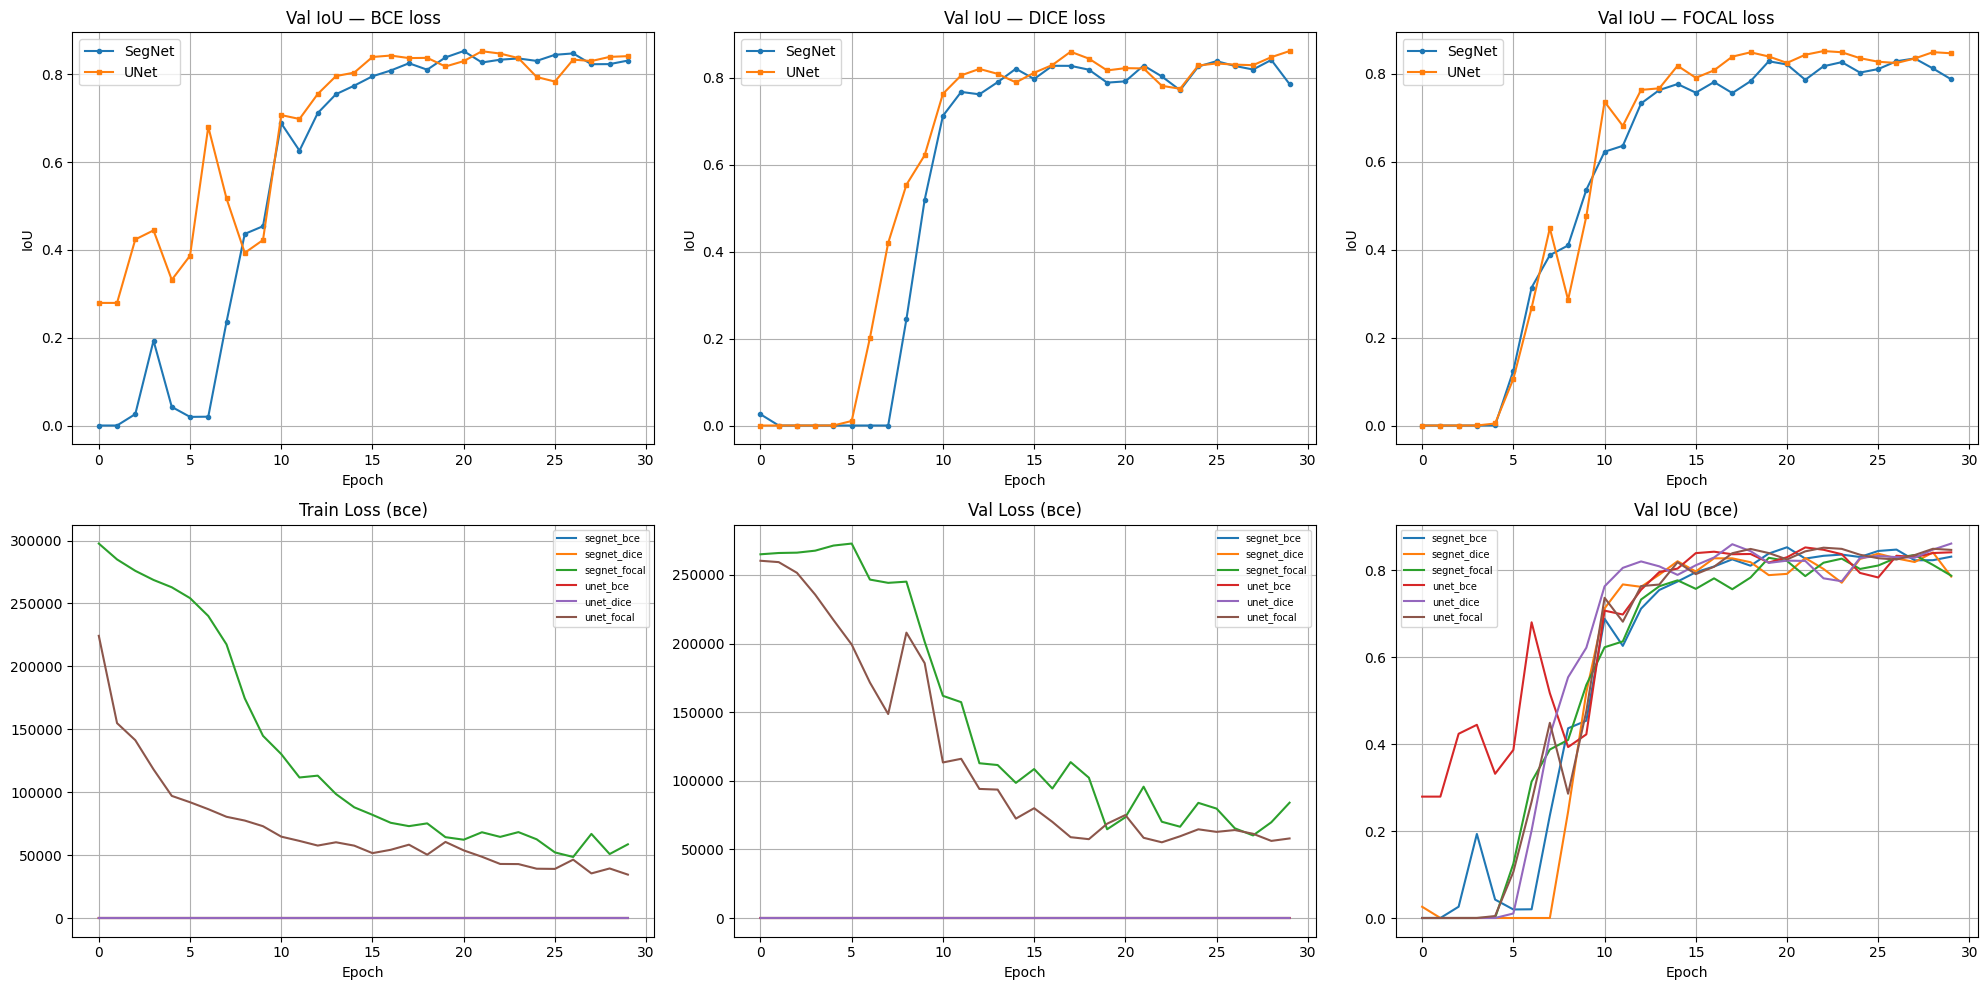

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

losses = ['bce', 'dice', 'focal']

# Верхний ряд — сравнение SegNet vs UNet по каждому лоссу
for i, loss_name in enumerate(losses):
    seg_key = f'segnet_{loss_name}'
    unet_key = f'unet_{loss_name}'

    axes[0, i].plot(results[seg_key]['val_iou'], label='SegNet', marker='o', markersize=3)
    axes[0, i].plot(results[unet_key]['val_iou'], label='UNet', marker='s', markersize=3)
    axes[0, i].set_title(f'Val IoU — {loss_name.upper()} loss')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('IoU')
    axes[0, i].legend()
    axes[0, i].grid(True)

# Нижний ряд — все 6 экспериментов вместе
for name, stats in results.items():
    axes[1, 0].plot(stats['train loss'], label=name)
axes[1, 0].set_title('Train Loss (все)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(True)

for name, stats in results.items():
    axes[1, 1].plot(stats['val_loss'], label=name)
axes[1, 1].set_title('Val Loss (все)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(True)

for name, stats in results.items():
    axes[1, 2].plot(stats['val_iou'], label=name)
axes[1, 2].set_title('Val IoU (все)')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].legend(fontsize=7)
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(f"\n{'Experiment':<20} {'Best IoU':<12} {'Final IoU':<12} {'Best Epoch':<12}")
print('-' * 56)
for name, stats in results.items():
    ious = stats['val_iou']
    best_iou = max(ious)
    best_epoch = ious.index(best_iou) + 1
    final_iou = ious[-1]
    print(f"{name:<20} {best_iou:<12.4f} {final_iou:<12.4f} {best_epoch:<12}")


Experiment           Best IoU     Final IoU    Best Epoch  
--------------------------------------------------------
segnet_bce           0.8527       0.8310       21          
segnet_dice          0.8407       0.7852       29          
segnet_focal         0.8348       0.7873       28          
unet_bce             0.8523       0.8411       22          
unet_dice            0.8612       0.8612       30          
unet_focal           0.8517       0.8466       23          


# Сравнение SegNet и UNet на трёх лоссах (BCE, Dice, Focal)

## 1. Какая модель даёт лучшие значения по метрике?

**UNet превосходит SegNet при каждом лоссе.** Лучший результат — **UNet + Dice loss** (IoU = 0.8612). При этом UNet стабильнее: его Final IoU практически не отличается от Best IoU (0.8612 vs 0.8612), тогда как SegNet заметно деградирует к концу обучения (например, segnet_dice: Best 0.8407 → Final 0.7852, потеря 5.5%).

Преимущество UNet объясняется **skip connections** — они передают детали из энкодера напрямую в декодер, что критично для точной локализации границ родинок. SegNet передаёт только индексы пулинга, теряя пространственную информацию.

## 2. Какая модель даёт лучшие значения по лоссам?

Графики Train/Val Loss нельзя сравнивать напрямую между разными функциями потерь (у BCE, Dice и Focal разные шкалы — focal loss достигает значений ~300000, тогда как dice и bce около 0–1). Однако внутри одного лосса видно:

- **BCE**: UNet и SegNet показывают схожую динамику, обе модели стабильно снижают val loss.
- **Dice**: UNet снижает val loss плавнее, SegNet показывает скачки.
- **Focal**: SegNet имеет аномально высокие значения лосса (сотни тысяч), что говорит о проблемах с масштабом — focal loss суммирует, а не усредняет. UNet справляется лучше.

## 3. Какая модель обучается быстрее?

**UNet обучается быстрее при BCE и Focal.** По графикам Val IoU видно, что UNet начинает выходить на плато уже к 10–12 эпохе, тогда как SegNet стартует позже (около 8–10 эпохи) и выходит на плато к 15–20 эпохе.

Исключение — **Dice loss**: обе модели долго «молчат» первые 5–8 эпох (IoU ≈ 0), а затем резко включаются. UNet при этом достигает лучшего результата, но позже (эпоха 30). Это характерное поведение Dice loss — он плохо работает на ранних этапах, когда предсказания далеки от ground truth.

По **Best Epoch**: segnet_bce (21) и unet_focal (23) сходятся быстрее всех. unet_dice (30) и segnet_dice (29) — медленнее всех.

## 4. Визуальное сравнение

UNet даёт более чёткие и точные границы родинок благодаря skip connections. SegNet склонен к более размытым краям и иногда пропускает мелкие детали формы. Особенно заметна разница на родинках с неровными границами — UNet лучше повторяет их контур.

## Общий вывод

- **Лучшая комбинация**: UNet + Dice loss (IoU = 0.8612, стабильный, без деградации)
- **Самая быстрая сходимость**: UNet + BCE или UNet + Focal
- **SegNet** уступает UNet по всем метрикам — skip connections дают существенное преимущество для задачи сегментации
- **Dice loss** даёт лучшее качество, но медленнее сходится; **BCE** — хороший баланс скорости и качества